# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from datetime import datetime
from itertools import permutations
from sklearn.metrics import f1_score, classification_report, r2_score, log_loss, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from catboost import CatBoostClassifier


## datasetes

### df

In [2]:
path = r'C:\Projects\Statbotics\RomiRotem\data\datasets\full_table2.csv'

df = pd.read_csv(path)

In [3]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


### sdf

In [5]:
path1 = r'C:\Projects\Statbotics\RomiRotem\full_project\code\to_frontend\summery_df.csv'

sdf = pd.read_csv(path1)

In [6]:
sdf['endGame'] = sdf['endGame'].map({'Nothiing': 0, 'Parked': 1, 'ShallowCage': 2, 'DeepCage': 3})
sdf['endGame'] = sdf['endGame'].fillna(0)

In [7]:
sdf['team_number'] = sdf['team_number'].astype(str).str.extract(r'(\d+)').astype(int)
sdf.set_index(sdf.columns[0], inplace=True)
sdf = sdf.groupby(level=0).mean(numeric_only=True)
sdf.index.name = None

In [8]:
sdf = sdf.sort_index()

In [9]:
sdf.loc[2486]

score                         92.296202
autoLine                       0.873583
autoReef_tba_botRowCount       0.058390
autoReef_tba_midRowCount       0.015306
autoReef_tba_topRowCount       1.620465
autoReef_trough                0.234127
foulCount                      0.197846
netAlgaeCount                  1.898810
techFoulCount                  0.812925
teleopReef_tba_botRowCount     1.448980
teleopReef_tba_midRowCount     2.953515
teleopReef_tba_topRowCount     7.177721
teleopReef_trough              1.661848
wallAlgaeCount                 0.747449
endGame                        2.000000
possition                      2.000000
quality                       -0.405392
Name: 2486, dtype: float64

# prepares

In [10]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


In [11]:
teams_to_drop = ['frc9990', 'frc9991', 'frc9992', 'frc9993', 'frc9994', 'frc9995', 'frc9996', 'frc9997', 'frc9998', 'frc9999']

for team in df['team_number'].unique():
    if df.loc[df['team_number'] == team].shape[0] < 10:
        teams_to_drop.append(team)

df = df[~df['team_number'].isin(teams_to_drop)]

In [12]:
df['win'] = df['winning_alliance'] == df['alliance']

C:\Users\user\AppData\Local\Temp\ipykernel_6688\1230158382.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['win'] = df['winning_alliance'] == df['alliance']


In [13]:
df["comp_level"] = df["comp_level"].map({'qm': 1, 'sf': 2, 'f': 3})
df['winning_alliance'] = df['winning_alliance'].map({'blue': 1, 'red': 2})
df['winning_alliance'] = df['winning_alliance'].fillna(0)
df['alliance'] = df['alliance'].map({'blue': 1, 'red': 2})
df['actual_time'] = pd.to_datetime(df['actual_time'], unit='s').dt.hour
df['team_number'] = df['team_number'].astype(str).str.extract(r'(\d+)').astype(int)

# pre-match data

In [14]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance,win
0,16,3,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",1.0,...,False,False,True,0.0,0.0,2783,124.0,1,2,False


In [15]:
df.loc[df['team_number'] == 991]

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance,win
452,0,1,2025azfg,2025azfg_qm52,52,1.741999e+09,1,1.741996e+09,"[{'key': 'HCsnR-Mmo1I', 'type': 'youtube'}]",1.0,...,False,False,False,0.0,2.0,991,49.0,1,2,False
483,19,1,2025azfg,2025azfg_qm80,80,1.742066e+09,1,1.742065e+09,"[{'key': 'szWijLLdCsA', 'type': 'youtube'}]",1.0,...,False,False,False,1.0,2.0,991,31.0,1,2,False
622,16,1,2025azrl2,2025azrl2_qm1,1,1.751129e+09,1,1.751129e+09,"[{'key': 'UzuB1Se-gDc', 'type': 'youtube'}]",1.0,...,True,False,False,0.0,1.0,991,51.0,1,2,False
633,17,1,2025azrl2,2025azrl2_qm3,3,1.751132e+09,1,1.751131e+09,"[{'key': '51_tn6sDH2g', 'type': 'youtube'}]",1.0,...,False,False,False,3.0,0.0,991,11.0,1,2,False
637,18,1,2025azrl2,2025azrl2_qm7,7,1.751135e+09,1,1.751134e+09,"[{'key': 'cKkopwnRChk', 'type': 'youtube'}]",2.0,...,False,False,False,12.0,2.0,991,109.0,1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97722,22,1,2025azrl5,2025azrl5_qm32,32,1.758408e+09,1,1.758407e+09,"[{'key': 'kciwF2fTwFY', 'type': 'youtube'}]",1.0,...,False,False,False,1.0,1.0,991,36.0,3,1,True
98789,22,1,2025caph,2025caph_qm36,36,1.740870e+09,1,1.740869e+09,"[{'key': '-77W7mN7dbg', 'type': 'youtube'}]",2.0,...,False,False,False,0.0,1.0,991,53.0,3,1,False
98823,18,1,2025caph,2025caph_qm67,67,1.740940e+09,1,1.740939e+09,"[{'key': 'McahZ6KQvu0', 'type': 'youtube'}]",2.0,...,False,False,False,8.0,6.0,991,90.0,3,1,False
110040,21,1,2025nvlv,2025nvlv_qm33,33,1.743198e+09,1,1.743196e+09,"[{'key': 'WrZRQtU9QGw', 'type': 'youtube'}]",1.0,...,False,False,False,8.0,9.0,991,85.0,3,1,True


In [16]:
pdf = df[['key', 'actual_time', 'comp_level', 'team_number', 'possition', 'alliance', 'win']]
#prematch data frame

In [17]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


In [18]:
pdf.loc[pdf['key'] == '2025alhu_qm10']

,key,actual_time,comp_level,team_number,possition,alliance,win
3,2025alhu_qm10,15,1,538,1,2,True
19400,2025alhu_qm10,15,1,2338,2,2,True
38797,2025alhu_qm10,15,1,2973,3,2,True
58194,2025alhu_qm10,15,1,3138,1,1,False
77591,2025alhu_qm10,15,1,3843,2,1,False
96988,2025alhu_qm10,15,1,4020,3,1,False


In [19]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,quality
1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,1.0,1.0,-23.344473
4,116.204545,0.977273,0.068182,0.045455,1.454545,0.340909,0.272727,2.840909,0.704545,3.636364,5.681818,6.431818,1.545455,1.522727,1.0,3.0,3.728177
8,119.888889,1.000000,0.037037,0.000000,2.777778,0.185185,0.185185,1.407407,0.629630,2.148148,4.592593,10.259259,1.111111,0.703704,3.0,3.0,12.070774
11,149.234375,0.984375,0.046875,0.000000,2.828125,0.375000,0.171875,4.109375,0.328125,3.671875,5.875000,9.921875,2.046875,0.953125,3.0,2.0,31.859901
16,153.065217,0.934783,0.000000,0.000000,3.304348,0.152174,0.282609,4.869565,0.695652,3.717391,6.869565,9.826087,2.456522,0.782609,3.0,1.0,24.112880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,75.458333,1.000000,0.083333,0.000000,0.708333,0.958333,0.166667,1.000000,0.625000,1.125000,1.416667,5.333333,4.500000,0.458333,1.0,1.0,-18.075492
10714,105.111111,0.888889,0.000000,0.000000,1.444444,1.000000,0.888889,1.555556,0.222222,1.777778,2.000000,9.111111,4.888889,0.888889,0.0,1.0,-3.279269
10905,51.000000,0.583333,0.166667,0.000000,0.250000,0.416667,0.083333,0.416667,0.750000,0.750000,0.250000,4.666667,0.583333,0.500000,1.0,1.0,-29.052520
10988,57.833333,0.750000,0.000000,0.166667,0.416667,0.166667,0.083333,0.666667,0.833333,0.750000,2.000000,4.083333,0.750000,0.750000,1.0,1.0,-20.519609


In [20]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


# logistic reggresion 2 teams

In [21]:
def alliance_pairs(data, sdf):
    if data is None or len(data) < 2:
        return pd.DataFrame()

    new_rows = []
    sdf_cols = sdf.columns.tolist()

    for (i1, row1), (i2, row2) in permutations(data.iterrows(), 2):
        
        new_row_data = {
            'key': row1['key'],
            'actual_time': row1['actual_time'],
            'comp_level': row1['comp_level'],
            'team_number1': row1['team_number'],
            'team_number2': row2['team_number'],
            'possition1': row1['possition'],
            'possition2': row2['possition'],
            'alliance': row1['alliance'],
            'win': row1['win']
        }
        
        t1 = row1['team_number']
        if t1 in sdf.index:
            stats1 = sdf.loc[t1]
            for col in sdf_cols:
                new_row_data[f'S_{col}_team1'] = stats1[col]

        t2 = row2['team_number']
        if t2 in sdf.index:
            stats2 = sdf.loc[t2]
            for col in sdf_cols:
                new_row_data[f'S_{col}_team2'] = stats2[col]

        new_rows.append(new_row_data)
        
    return pd.DataFrame(new_rows)


In [22]:

frames = []
for k in pdf['key'].unique():
    for i in range(1, 3):
        subset = pdf[(pdf['key'] == k) & (pdf['alliance'] == i)]
        
        processed_data = alliance_pairs(subset, sdf)
        
        if not processed_data.empty:
            frames.append(processed_data)

if frames:
    d2pdf = pd.concat(frames, ignore_index=True)
else:
    d2pdf = pd.DataFrame()
#d2pdf = duplicated prematch data frame

In [23]:
d2pdf

,key,actual_time,comp_level,team_number1,team_number2,possition1,possition2,alliance,win,S_score_team1,...,S_netAlgaeCount_team2,S_techFoulCount_team2,S_teleopReef_tba_botRowCount_team2,S_teleopReef_tba_midRowCount_team2,S_teleopReef_tba_topRowCount_team2,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2
0,2025alhu_f1m1,16,3,2338,4020,1,2,1,True,177.288462,...,2.133333,0.200000,6.155556,8.422222,10.177778,2.466667,2.511111,3.0,3.0,41.884800
1,2025alhu_f1m1,16,3,2338,10011,1,3,1,True,177.288462,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
2,2025alhu_f1m1,16,3,4020,2338,2,1,1,True,166.888889,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464
3,2025alhu_f1m1,16,3,4020,10011,2,3,1,True,166.888889,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
4,2025alhu_f1m1,16,3,10011,2338,3,1,1,True,114.166667,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221637,2025tuis_qm45,15,1,9523,6014,3,2,1,True,79.241379,...,1.950000,0.350000,3.350000,4.550000,7.150000,2.050000,0.850000,1.0,2.0,-0.261680
221638,2025tuis2_qm35,12,1,10528,9610,2,3,1,False,54.272727,...,0.777778,1.388889,0.666667,0.555556,3.055556,2.555556,0.944444,0.0,1.0,-28.273517
221639,2025tuis2_qm35,12,1,9610,10528,3,2,1,False,48.333333,...,0.181818,0.909091,1.818182,2.000000,1.000000,4.909091,0.181818,1.0,3.0,-10.539770
221640,2025tuis3_qm44,14,1,10598,9483,2,3,1,True,97.114286,...,2.162791,0.395349,6.395349,8.581395,9.790698,4.139535,0.511628,1.0,2.0,50.141544


In [24]:
X = d2pdf.drop(['win', 'key', 'alliance'], axis = 1)
y = d2pdf['win']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)

In [26]:
X_test1, X_test2, y_test1, y_test2 = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [27]:
y_train

39018     False
185572     True
90004      True
84902      True
109431     True
          ...  
119879    False
103694     True
131932    False
146867    False
121958    False
Name: win, Length: 132985, dtype: bool

In [28]:
# X_train["label"] = y_train

In [29]:
# X_train.groupby(["comp_level", "label"]).count()

In [30]:
X_train = X_train.astype(float)

In [31]:
X_train.iloc[63]

actual_time                             20.000000
comp_level                               1.000000
team_number1                          2486.000000
team_number2                          9091.000000
possition1                               3.000000
possition2                               2.000000
S_score_team1                           92.296202
S_autoLine_team1                         0.873583
S_autoReef_tba_botRowCount_team1         0.058390
S_autoReef_tba_midRowCount_team1         0.015306
S_autoReef_tba_topRowCount_team1         1.620465
S_autoReef_trough_team1                  0.234127
S_foulCount_team1                        0.197846
S_netAlgaeCount_team1                    1.898810
S_techFoulCount_team1                    0.812925
S_teleopReef_tba_botRowCount_team1       1.448980
S_teleopReef_tba_midRowCount_team1       2.953515
S_teleopReef_tba_topRowCount_team1       7.177721
S_teleopReef_trough_team1                1.661848
S_wallAlgaeCount_team1                   0.747449


In [32]:

clf = LogisticRegression(random_state=0).fit(X_train, y_train)

c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## threshhold 0.5

In [33]:
y_pred = clf.predict(X_test1)
f1 = f1_score(y_test1, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6179


In [34]:
print("0.5: \n",classification_report(y_test1, y_pred))

0.5: 
               precision    recall  f1-score   support

       False       0.62      0.66      0.64     21952
        True       0.64      0.60      0.62     22376

    accuracy                           0.63     44328
   macro avg       0.63      0.63      0.63     44328
weighted avg       0.63      0.63      0.63     44328



## threshhold k

In [35]:
ks = {}

In [36]:
for k in range(10):
    y_probs = clf.predict_proba(X_test2)[:, 1]
    custom_threshold = k/10
    y_pred_custom = (y_probs >= custom_threshold).astype(int)
    f1 = f1_score(y_test2, y_pred_custom)
    ks[k/10] = f1
    print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6671
F1-Score: 0.6671
F1-Score: 0.6678
F1-Score: 0.6789
F1-Score: 0.6793
F1-Score: 0.6157
F1-Score: 0.4689
F1-Score: 0.2725
F1-Score: 0.0925
F1-Score: 0.0088


In [37]:
ks

{0.0: 0.6671377241908084,
 0.1: 0.6671377241908084,
 0.2: 0.6678211112784219,
 0.3: 0.6788544926062994,
 0.4: 0.6792740525865596,
 0.5: 0.6156997858273582,
 0.6: 0.4689397754539799,
 0.7: 0.2724641928275761,
 0.8: 0.09245762711864407,
 0.9: 0.008788449466415568}

<Axes: >

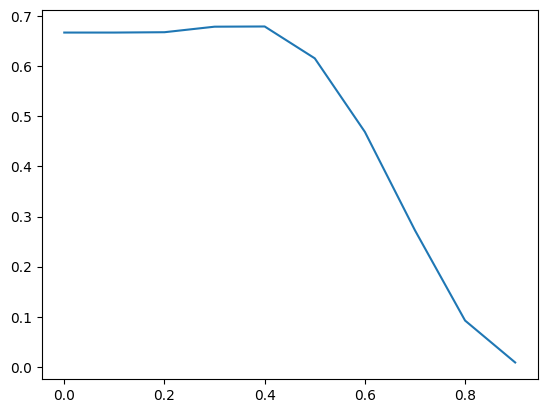

In [38]:
sns.lineplot(x=list(ks.keys()), y=list(ks.values()))

In [39]:
y_probs2 = clf.predict_proba(X_test2)[:, 1]
custom_threshold = 0.4
y_pred_custom = (y_probs2 >= custom_threshold).astype(int)
f1 = f1_score(y_test2, y_pred_custom)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6793


In [40]:
print("0.4: \n",classification_report(y_test2, y_pred_custom))

0.4: 
               precision    recall  f1-score   support

       False       0.69      0.40      0.51     22141
        True       0.58      0.82      0.68     22188

    accuracy                           0.61     44329
   macro avg       0.64      0.61      0.59     44329
weighted avg       0.64      0.61      0.59     44329



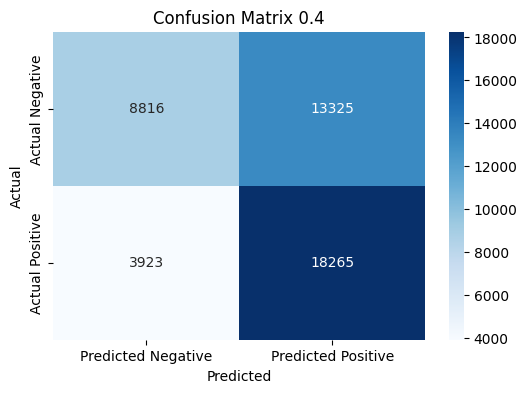

In [41]:
cm = confusion_matrix(y_test2, y_pred_custom)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix 0.4')
plt.show()

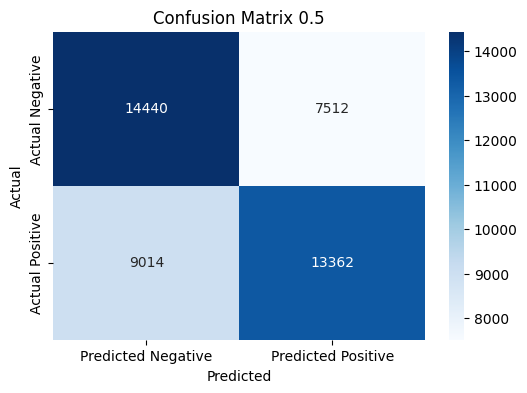

In [42]:
cm = confusion_matrix(y_test1, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix 0.5')
plt.show()

In [43]:
print("0.5: ",r2_score(y_test1, y_pred))
print("0.4: ",r2_score(y_test2, y_pred_custom))

0.5:  -0.49138351456318774
0.4:  -0.5563644015577855


In [44]:
print("0.5: ",log_loss(y_test1, y_pred))
print("0.4: ",log_loss(y_test2, y_pred_custom))

0.5:  13.437498102972162
0.4:  14.024248994010524


In [45]:
y_probs_full = clf.predict_proba(X_test)[:, 1]
custom_threshold = 0.5
y_pred_full = (y_probs_full >= custom_threshold).astype(int)

In [46]:
print(len(y_test),"\n", len(y_probs_full),"\n",len(y_pred_full.astype(bool)) ,"\n", len(X_test["team_number1"]), "\n", len(X_test["team_number2"]))

88657 
 88657 
 88657 
 88657 
 88657


In [47]:
tdf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_full.astype(bool),
    'Probability': y_probs_full,
    "team1": X_test["team_number1"],
    "team2": X_test["team_number2"]
})
# test df

In [48]:
tdf["Wrong"] = tdf["Actual"] != tdf["Predicted"]

In [49]:
tdf

,Actual,Predicted,Probability,team1,team2,Wrong
114633,False,True,0.591855,1732,8122,True
152596,True,True,0.546182,3624,4122,False
158710,False,False,0.391005,3247,2333,False
189490,True,False,0.434247,9492,5613,True
111866,True,True,0.622949,862,5084,False
...,...,...,...,...,...,...
170864,False,False,0.209673,2733,2898,False
151323,False,False,0.409072,7165,5881,False
173719,False,False,0.356436,5113,1647,False
158991,True,False,0.423373,2080,10219,True


In [50]:
w = 0.8
wtdf = tdf.loc[(tdf["Wrong"]) & ((tdf["Probability"] > w) | (tdf["Probability"] < (1-w)))]
# wierds test df

In [51]:
wtdf

,Actual,Predicted,Probability,team1,team2,Wrong
46646,False,True,0.804488,973,2075,True
121802,False,True,0.866979,341,5895,True
32090,False,True,0.850215,6329,4481,True
9904,False,True,0.854325,3128,5468,True
26792,False,True,0.813610,16,180,True
...,...,...,...,...,...,...
67791,False,True,0.805286,88,125,True
55593,False,True,0.870878,2075,868,True
55744,False,True,0.875395,694,2075,True
72011,True,False,0.194756,9056,4473,True


In [52]:
d2pdf.loc[(d2pdf["team_number1"] == 2056) & (d2pdf["team_number2"] == 1690)]

,key,actual_time,comp_level,team_number1,team_number2,possition1,possition2,alliance,win,S_score_team1,...,S_netAlgaeCount_team2,S_techFoulCount_team2,S_teleopReef_tba_botRowCount_team2,S_teleopReef_tba_midRowCount_team2,S_teleopReef_tba_topRowCount_team2,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2
55477,2025iri_f1m1,20,3,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
55489,2025iri_f1m2,21,3,2056,1690,3,2,2,False,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56581,2025iri_sf11m1,19,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56617,2025iri_sf1m1,18,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56689,2025iri_sf7m1,19,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104


In [53]:
d2pdf["S_teleopReef_trough_team1"].describe()

count    221642.000000
mean          2.348363
std           1.374218
min           0.200000
25%           1.541667
50%           2.000000
75%           2.642857
max          13.392157
Name: S_teleopReef_trough_team1, dtype: float64

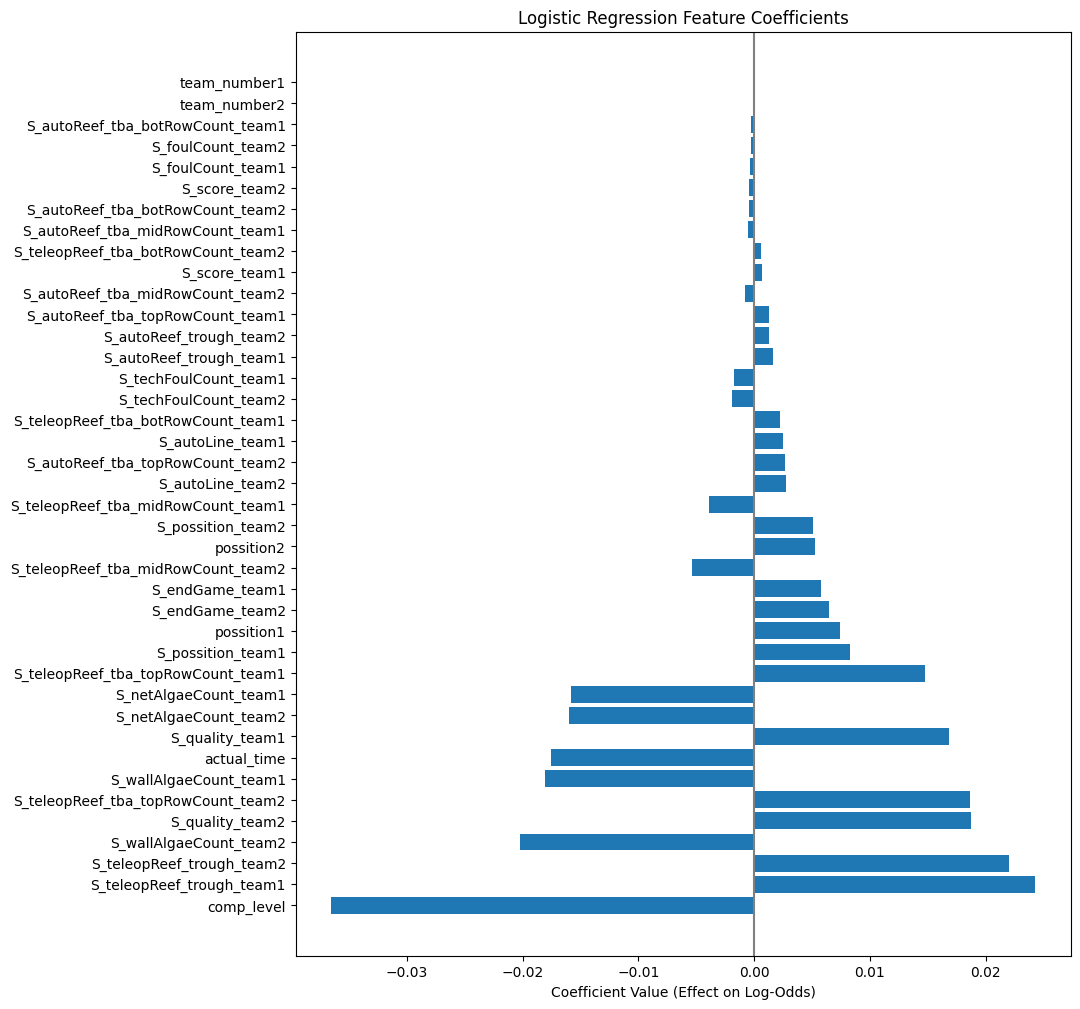

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
coefficients = clf.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Absolute_Importance': abs(coefficients)
})
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)
# print(feature_importance)
plt.figure(figsize=(10, 12))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value (Effect on Log-Odds)")
plt.axvline(x=0, color='.5')
plt.show()

## improvments

### normalize

In [55]:
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(X.drop(['team_number1', 'team_number2'], axis = 1))
nX = pd.DataFrame(scaled_array, columns=X.drop(['team_number1', 'team_number2'], axis = 1).columns, index=X.drop(['team_number1', 'team_number2'], axis = 1).index)

In [56]:
nX = pd.concat([nX, d2pdf[['comp_level', 'team_number1', 'team_number2', 'possition1', 'possition2']]], axis = 1)

In [57]:
nX

,actual_time,comp_level,possition1,possition2,S_score_team1,S_autoLine_team1,S_autoReef_tba_botRowCount_team1,S_autoReef_tba_midRowCount_team1,S_autoReef_tba_topRowCount_team1,S_autoReef_trough_team1,...,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2,comp_level,team_number1,team_number2,possition1,possition2
0,0.695652,1.0,0.0,0.5,0.719568,1.000000,0.104701,0.063077,0.800755,0.065859,...,0.171819,0.308112,1.000000,1.0,0.679087,3,2338,4020,1,2
1,0.695652,1.0,0.0,1.0,0.719568,1.000000,0.104701,0.063077,0.800755,0.065859,...,0.043271,0.171268,0.333333,1.0,0.327693,3,2338,10011,1,3
2,0.695652,1.0,0.5,0.0,0.668062,1.000000,0.051852,0.121481,0.727540,0.030441,...,0.229740,0.127419,1.000000,0.5,0.698370,3,4020,2338,2,1
3,0.695652,1.0,0.5,1.0,0.668062,1.000000,0.051852,0.121481,0.727540,0.030441,...,0.043271,0.171268,0.333333,1.0,0.327693,3,4020,10011,2,3
4,0.695652,1.0,1.0,0.0,0.406946,1.000000,0.097222,0.000000,0.341034,0.085616,...,0.229740,0.127419,1.000000,0.5,0.698370,3,10011,2338,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221637,0.652174,0.0,1.0,0.5,0.233972,1.000000,0.107280,0.000000,0.186330,0.035427,...,0.140235,0.104294,0.333333,0.5,0.381674,1,9523,6014,3,2
221638,0.521739,0.0,0.5,1.0,0.110310,1.000000,0.000000,0.000000,0.028896,0.342466,...,0.178557,0.115883,0.000000,0.0,0.184004,1,10528,9610,2,3
221639,0.521739,0.0,1.0,0.5,0.080894,0.055556,0.043210,0.000000,0.026488,0.057078,...,0.356961,0.022309,0.333333,1.0,0.309145,1,9610,10528,3,2
221640,0.608696,0.0,0.5,1.0,0.322490,0.971429,0.066667,0.000000,0.263367,0.078278,...,0.298627,0.062776,0.333333,0.5,0.737352,1,10598,9483,2,3


### cross val

In [58]:
y_probs_cv = cross_val_predict(clf, nX, y, cv=5, method='predict_proba')[:, 1]

custom_threshold = 0.5
y_pred_cv = (y_probs_cv >= custom_threshold).astype(int)

print(classification_report(y, y_pred_cv))

c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

              precision    recall  f1-score   support

       False       0.60      0.66      0.63    110426
        True       0.63      0.57      0.60    111216

    accuracy                           0.62    221642
   macro avg       0.62      0.62      0.61    221642
weighted avg       0.62      0.62      0.61    221642



c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
f1_score(y, y_pred_cv)

0.5980927072437546

# logistic regresion 3 teams

In [60]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


In [61]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,quality
1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,1.0,1.0,-23.344473
4,116.204545,0.977273,0.068182,0.045455,1.454545,0.340909,0.272727,2.840909,0.704545,3.636364,5.681818,6.431818,1.545455,1.522727,1.0,3.0,3.728177
8,119.888889,1.000000,0.037037,0.000000,2.777778,0.185185,0.185185,1.407407,0.629630,2.148148,4.592593,10.259259,1.111111,0.703704,3.0,3.0,12.070774
11,149.234375,0.984375,0.046875,0.000000,2.828125,0.375000,0.171875,4.109375,0.328125,3.671875,5.875000,9.921875,2.046875,0.953125,3.0,2.0,31.859901
16,153.065217,0.934783,0.000000,0.000000,3.304348,0.152174,0.282609,4.869565,0.695652,3.717391,6.869565,9.826087,2.456522,0.782609,3.0,1.0,24.112880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,75.458333,1.000000,0.083333,0.000000,0.708333,0.958333,0.166667,1.000000,0.625000,1.125000,1.416667,5.333333,4.500000,0.458333,1.0,1.0,-18.075492
10714,105.111111,0.888889,0.000000,0.000000,1.444444,1.000000,0.888889,1.555556,0.222222,1.777778,2.000000,9.111111,4.888889,0.888889,0.0,1.0,-3.279269
10905,51.000000,0.583333,0.166667,0.000000,0.250000,0.416667,0.083333,0.416667,0.750000,0.750000,0.250000,4.666667,0.583333,0.500000,1.0,1.0,-29.052520
10988,57.833333,0.750000,0.000000,0.166667,0.416667,0.166667,0.083333,0.666667,0.833333,0.750000,2.000000,4.083333,0.750000,0.750000,1.0,1.0,-20.519609


In [62]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance,win
0,16,3,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",1.0,...,False,False,True,0.0,0.0,2783,124.0,1,2,False
1,16,3,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",1.0,...,True,True,False,0.0,0.0,2783,144.0,1,2,False
2,13,1,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",2.0,...,False,False,False,5.0,2.0,5045,129.0,1,2,True
3,15,1,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",2.0,...,True,True,True,1.0,0.0,538,112.0,1,2,True
4,15,1,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",1.0,...,True,True,True,1.0,1.0,6107,61.0,1,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116366,0,1,2025xxmel,2025xxmel_qm7,7,1.752281e+09,1,1.752280e+09,[],2.0,...,False,False,False,8.0,0.0,7128,66.0,3,1,False
116368,1,1,2025xxmel,2025xxmel_qm9,9,1.752283e+09,1,1.752281e+09,[],1.0,...,False,False,False,9.0,0.0,6996,91.0,3,1,True
116369,4,2,2025xxmel,2025xxmel_sf10m1,1,1.752382e+09,10,1.752382e+09,[],2.0,...,True,True,True,9.0,0.0,5648,70.0,3,1,False
116370,4,2,2025xxmel,2025xxmel_sf11m1,1,1.752383e+09,11,1.752383e+09,[],2.0,...,False,True,True,6.0,0.0,10002,90.0,3,1,False


In [63]:
def alliance_trips(data, sdf):
    if data is None or len(data) < 3:
        return pd.DataFrame()

    sdf_cols = sdf.columns.tolist()
    
    row1 = data.iloc[0]
    row2 = data.iloc[1]
    row3 = data.iloc[2]

    new_row_data = {
        'key': row1['key'],
        'actual_time': row1['actual_time'],
        'comp_level': row1['comp_level'],
        'team_number1': row1['team_number'],
        'team_number2': row2['team_number'],
        'team_number3': row3['team_number'],
        'possition1': row1['possition'],
        'possition2': row2['possition'],
        'possition3': row3['possition'],
        'alliance': row1['alliance'],
        'win': row1['win']
    }
    
    t1 = row1['team_number']
    if t1 in sdf.index:
        for col in sdf_cols:
            new_row_data[f'S_{col}_team1'] = sdf.loc[t1, col]

    t2 = row2['team_number']
    if t2 in sdf.index:
        for col in sdf_cols:
            new_row_data[f'S_{col}_team2'] = sdf.loc[t2, col]
    
    t3 = row3['team_number']
    if t3 in sdf.index:
        for col in sdf_cols:
            new_row_data[f'S_{col}_team3'] = sdf.loc[t3, col]

    return pd.DataFrame([new_row_data])

In [64]:
frames = []
for k in pdf['key'].unique():
    for i in range(1, 3):
        subset = pdf[(pdf['key'] == k) & (pdf['alliance'] == i)]
        
        processed_data = alliance_trips(subset, sdf)
        
        if not processed_data.empty:
            frames.append(processed_data)

if frames:
    d3pdf = pd.concat(frames, ignore_index=True)
else:
    d3pdf = pd.DataFrame()


In [65]:
d3pdf

,key,actual_time,comp_level,team_number1,team_number2,team_number3,possition1,possition2,possition3,alliance,...,S_netAlgaeCount_team3,S_techFoulCount_team3,S_teleopReef_tba_botRowCount_team3,S_teleopReef_tba_midRowCount_team3,S_teleopReef_tba_topRowCount_team3,S_teleopReef_trough_team3,S_wallAlgaeCount_team3,S_endGame_team3,S_possition_team3,S_quality_team3
0,2025alhu_f1m1,16,3,2338,4020,10011,1,2,3,1,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
1,2025alhu_f1m1,16,3,2783,4028,7111,1,2,3,2,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
2,2025alhu_f1m2,16,3,2338,4020,10011,1,2,3,1,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
3,2025alhu_f1m2,16,3,2783,4028,7111,1,2,3,2,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
4,2025alhu_qm1,13,1,2973,6107,9410,1,2,3,1,...,2.444444,0.407407,1.037037,4.037037,8.407407,1.407407,0.703704,3.0,3.0,7.840745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36339,2025tuhc_qm57,6,1,7444,8151,6838,1,2,3,1,...,1.361111,0.916667,1.861111,3.833333,8.333333,2.583333,1.083333,1.0,2.0,12.381515
36340,2025tuis3_qm24,11,1,4972,10043,6459,1,2,3,1,...,1.878049,0.853659,4.000000,6.756098,9.536585,2.975610,0.560976,1.0,2.0,32.623076
36341,2025tuis3_qm47,14,1,7742,10428,9155,1,2,3,1,...,0.300000,0.400000,2.600000,2.000000,3.500000,3.200000,0.400000,1.0,1.0,-7.902197
36342,2025wimc_qm30,22,1,1091,8744,2062,1,2,3,1,...,1.588235,0.294118,2.676471,4.000000,5.588235,1.647059,0.500000,1.0,3.0,-22.158574


In [66]:
flattened_rows = []

base_cols = ['key', 'actual_time', 'comp_level']

cols_to_suffix = [col for col in d3pdf.columns if col not in base_cols]

for k in d3pdf['key'].unique():
    match_data = d3pdf[d3pdf['key'] == k]
    
    if match_data.empty:
        continue
        
    first_row = match_data.iloc[0]
    new_row = {
        'key': first_row['key'],
        'actual_time': first_row['actual_time'],
        'comp_level': first_row['comp_level']
    }
    
    row_all1 = match_data[match_data['alliance'] == 1]
    row_all2 = match_data[match_data['alliance'] == 2]
    
    if not row_all1.empty:
        r1 = row_all1.iloc[0]
        for col in cols_to_suffix:
            new_row[f"{col}_all1"] = r1[col]
            
    if not row_all2.empty:
        r2 = row_all2.iloc[0]
        for col in cols_to_suffix:
            new_row[f"{col}_all2"] = r2[col]
            
    flattened_rows.append(new_row)

wd3pdf = pd.DataFrame(flattened_rows)
#wd3pdf = wide duplicated 3 prematch data frame

In [67]:
cwd3pdf = wd3pdf.dropna()

In [68]:
cwd3pdf

,key,actual_time,comp_level,team_number1_all1,team_number2_all1,team_number3_all1,possition1_all1,possition2_all1,possition3_all1,alliance_all1,...,S_netAlgaeCount_team3_all2,S_techFoulCount_team3_all2,S_teleopReef_tba_botRowCount_team3_all2,S_teleopReef_tba_midRowCount_team3_all2,S_teleopReef_tba_topRowCount_team3_all2,S_teleopReef_trough_team3_all2,S_wallAlgaeCount_team3_all2,S_endGame_team3_all2,S_possition_team3_all2,S_quality_team3_all2
0,2025alhu_f1m1,16,3,2338.0,4020.0,10011.0,1.0,2.0,3.0,1.0,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
1,2025alhu_f1m2,16,3,2338.0,4020.0,10011.0,1.0,2.0,3.0,1.0,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
2,2025alhu_qm1,13,1,2973.0,6107.0,9410.0,1.0,2.0,3.0,1.0,...,2.133333,0.200000,6.155556,8.422222,10.177778,2.466667,2.511111,3.0,3.0,41.884800
3,2025alhu_qm10,15,1,3138.0,3843.0,4020.0,1.0,2.0,3.0,1.0,...,1.300000,0.850000,1.050000,1.300000,6.100000,1.000000,0.650000,1.0,1.0,-25.656720
4,2025alhu_qm11,15,1,7428.0,8772.0,4028.0,1.0,2.0,3.0,1.0,...,2.030303,0.287879,2.257576,4.272727,7.878788,2.363636,1.530303,3.0,1.0,3.435763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18459,2025xxmel_qm27,4,1,5584.0,6996.0,9189.0,1.0,2.0,3.0,1.0,...,1.000000,0.203704,3.074074,5.111111,9.888889,2.296296,0.666667,3.0,2.0,26.421816
18466,2025xxmel_qm39,6,1,9986.0,5648.0,6497.0,1.0,2.0,3.0,1.0,...,0.703704,0.259259,1.444444,0.851852,3.259259,6.629630,0.370370,1.0,2.0,3.559700
18470,2025xxmel_qm46,23,1,4774.0,9976.0,9986.0,1.0,2.0,3.0,1.0,...,0.607143,0.392857,1.857143,1.678571,3.571429,2.428571,0.392857,1.0,2.0,-10.461085
18476,2025xxmel_qm57,1,1,4774.0,4537.0,9974.0,1.0,2.0,3.0,1.0,...,0.454545,0.303030,1.909091,2.272727,6.818182,3.484848,0.424242,1.0,3.0,13.843637


In [69]:
y = cwd3pdf['win_all1'].astype(int)

cols_to_drop = ['key', 'win_all1', 'win_all2', 'alliance_all1', 'alliance_all2', 'actual_time']
team_cols = [col for col in cwd3pdf.columns if 'team_number' in col]
cols_to_drop.extend(team_cols)

X = cwd3pdf.drop(columns=cols_to_drop, errors='ignore')
X = X.select_dtypes(include=['number'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [70]:
print(f"Model F1 score: {f1_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model F1 score: 78.77%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      3740
           1       0.79      0.78      0.79      3319

    accuracy                           0.80      7059
   macro avg       0.80      0.80      0.80      7059
weighted avg       0.80      0.80      0.80      7059



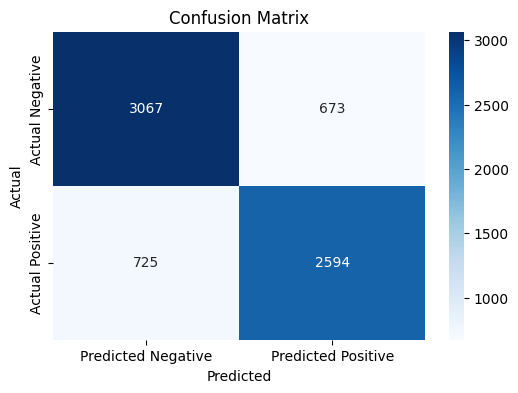

In [71]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [72]:
pipeline = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=42)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

In [73]:
print("Cross-Validation Accuracy Scores (5 Folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("-" * 30)
print(f"Mean CV Accuracy:   {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard Deviation: {np.std(cv_scores) * 100:.2f}%")

Cross-Validation Accuracy Scores (5 Folds):
Fold 1: 79.05%
Fold 2: 78.71%
Fold 3: 79.11%
Fold 4: 77.32%
Fold 5: 77.01%
------------------------------
Mean CV Accuracy:   78.24%
Standard Deviation: 0.89%


# catboost

In [74]:
best_depth = None
best_f1_score = 0.0
f1_scores_history = [] 

print("Testing CatBoost Depths:")
print("-" * 30)

for current_depth in range(1,10):
    
    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1, 
        depth=current_depth,
        verbose=0, 
        random_state=42
    )
    
    cat_model.fit(X_train, y_train)
    y_pred = cat_model.predict(X_test)
    
    current_f1 = f1_score(y_test, y_pred)
    f1_scores_history.append(current_f1)
    
    print(f"Depth {current_depth}: {current_f1 * 100:.2f}%")
    
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_depth = current_depth

print("-" * 30)
print(f"Optimal Depth found: {best_depth}")
print(f"Highest Test F1 Score: {best_f1_score * 100:.2f}%")

Testing CatBoost Depths:
------------------------------
Depth 1: 77.33%
Depth 2: 77.63%
Depth 3: 77.22%
Depth 4: 76.93%
Depth 5: 77.49%
Depth 6: 77.07%
Depth 7: 76.89%
Depth 8: 77.03%
Depth 9: 76.71%
------------------------------
Optimal Depth found: 2
Highest Test F1 Score: 77.63%


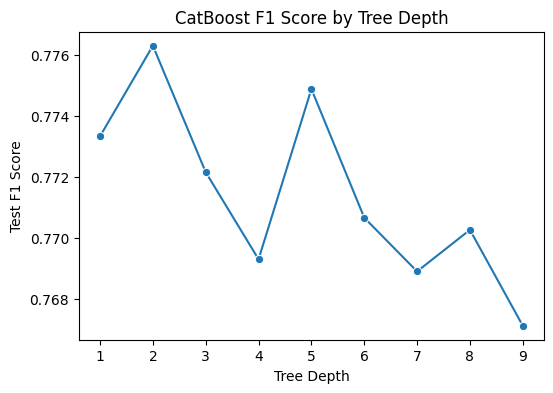

In [75]:
plt.figure(figsize=(6, 4))
sns.lineplot(x=range(1,10), y=f1_scores_history, marker='o')

plt.title('CatBoost F1 Score by Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Test F1 Score')

plt.show()

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1, 
    depth=6,
    verbose=0, 
    random_state=42
)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)

test_f1_score = f1_score(y_test, y_pred)

print("CatBoost Train/Test Split Performance:")
print("-" * 30)
print(f"Test f1 Score: {test_f1_score * 100:.2f}%")


CatBoost Train/Test Split Performance:
------------------------------
Test f1 Score: 77.71%


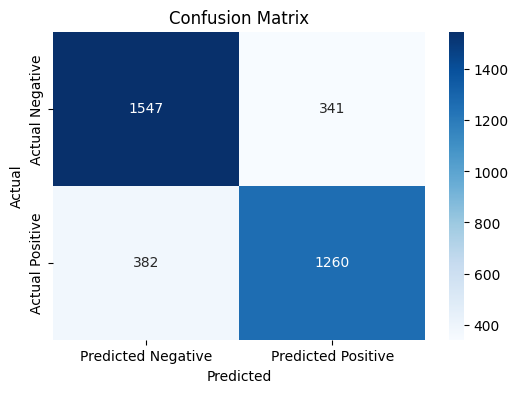

In [77]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [78]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1, 
    depth=6,
    verbose=0, 
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(cat_model, X, y, cv=cv, scoring='f1')

print("CatBoost Cross-Validation f1 Scores (5 Folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("-" * 30)
print(f"Mean CV f1:   {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard Deviation: {np.std(cv_scores) * 100:.2f}%")

CatBoost Cross-Validation f1 Scores (5 Folds):
Fold 1: 78.34%
Fold 2: 76.62%
Fold 3: 78.91%
Fold 4: 76.01%
Fold 5: 75.91%
------------------------------
Mean CV f1:   77.16%
Standard Deviation: 1.24%


In [79]:
X

,comp_level,possition1_all1,possition2_all1,possition3_all1,S_score_team1_all1,S_autoLine_team1_all1,S_autoReef_tba_botRowCount_team1_all1,S_autoReef_tba_midRowCount_team1_all1,S_autoReef_tba_topRowCount_team1_all1,S_autoReef_trough_team1_all1,...,S_netAlgaeCount_team3_all2,S_techFoulCount_team3_all2,S_teleopReef_tba_botRowCount_team3_all2,S_teleopReef_tba_midRowCount_team3_all2,S_teleopReef_tba_topRowCount_team3_all2,S_teleopReef_trough_team3_all2,S_wallAlgaeCount_team3_all2,S_endGame_team3_all2,S_possition_team3_all2,S_quality_team3_all2
0,3,1.0,2.0,3.0,177.288462,1.000000,0.134615,0.115385,5.038462,0.192308,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
1,3,1.0,2.0,3.0,177.288462,1.000000,0.134615,0.115385,5.038462,0.192308,...,2.592593,0.074074,1.222222,4.000000,5.185185,1.481481,0.925926,1.0,3.0,-17.909937
2,1,1.0,2.0,3.0,68.800000,0.900000,0.050000,0.000000,0.600000,0.300000,...,2.133333,0.200000,6.155556,8.422222,10.177778,2.466667,2.511111,3.0,3.0,41.884800
3,1,1.0,2.0,3.0,75.090909,0.954545,0.136364,0.000000,0.545455,0.272727,...,1.300000,0.850000,1.050000,1.300000,6.100000,1.000000,0.650000,1.0,1.0,-25.656720
4,1,1.0,2.0,3.0,111.400000,1.000000,0.000000,0.000000,1.833333,0.133333,...,2.030303,0.287879,2.257576,4.272727,7.878788,2.363636,1.530303,3.0,1.0,3.435763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18459,1,1.0,2.0,3.0,118.060606,1.000000,0.151515,0.212121,2.090909,0.363636,...,1.000000,0.203704,3.074074,5.111111,9.888889,2.296296,0.666667,3.0,2.0,26.421816
18466,1,1.0,2.0,3.0,115.689655,1.000000,0.103448,0.034483,1.862069,0.551724,...,0.703704,0.259259,1.444444,0.851852,3.259259,6.629630,0.370370,1.0,2.0,3.559700
18470,1,1.0,2.0,3.0,88.375000,1.000000,0.156250,0.062500,0.250000,0.906250,...,0.607143,0.392857,1.857143,1.678571,3.571429,2.428571,0.392857,1.0,2.0,-10.461085
18476,1,1.0,2.0,3.0,88.375000,1.000000,0.156250,0.062500,0.250000,0.906250,...,0.454545,0.303030,1.909091,2.272727,6.818182,3.484848,0.424242,1.0,3.0,13.843637


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

cat_model = CatBoostClassifier(verbose=0, random_state=42)

param_grid = {
    'iterations': [300, 500, 700],
    'learning_rate': [0.05, 0.1, 0.2], 
    'depth': [4, 6, 8]
}

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

print("Running Grid Search to find the best F1 model...")
grid_search.fit(X_train, y_train)

print("-" * 30)
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_ * 100:.2f}%")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_f1_score = f1_score(y_test, y_pred)

print("\nFinal Hold-Out Test Performance:")
print("-" * 30)
print(f"Test F1 Score: {test_f1_score * 100:.2f}%")

Running Grid Search to find the best F1 model...
------------------------------
Best Parameters Found: {'depth': 4, 'iterations': 300, 'learning_rate': 0.05}
Best CV F1 Score: 77.50%

Final Hold-Out Test Performance:
------------------------------
Test F1 Score: 77.81%


In [ ]:
# cross validation and grid search cv
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_model = CatBoostClassifier(verbose=0, random_state=42)
param_grid = {
    'iterations': [300, 500],
    'learning_rate': [0.05, 0.1], 
    'depth': [4, 6]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

print("Running Grid Search with 5-Fold Stratified CV...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best internal CV F1: {grid_search.best_score_ * 100:.2f}%")

best_model = grid_search.best_estimator_
final_test_f1 = f1_score(y_test, best_model.predict(X_test))

print("-" * 30)
print(f"Final Unseen Test F1 Score: {final_test_f1 * 100:.2f}%")

Running Grid Search with 5-Fold Stratified CV...
Best Parameters: {'depth': 4, 'iterations': 500, 'learning_rate': 0.05}
Best internal CV F1: 77.48%
------------------------------
Final Unseen Test F1 Score: 78.01%


# inference prepares

In [87]:
best_model.fit(X, y)
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [88]:
best_model.save_model("catboost_model.cbm")
joblib.dump(pipeline, "LR_model.pkl")

['LR_model.pkl']

In [89]:
X.to_csv(r"C:\Projects\Statbotics\RomiRotem\data\datasets\X.csv", index=False)

In [90]:
def predict_match(red_dict, blue_dict, comp_level, model_type='CB'):

    row_data = {'comp_level': comp_level}
    
    for i, (team, pos) in enumerate(red_dict.items(), start=1):
        row_data[f'possition{i}_all1'] = pos
        
        if team in sdf.index:
            for col in sdf.columns:
                row_data[f'S_{col}_team{i}_all1'] = sdf.loc[team, col]
        else:
            for col in sdf.columns:
                row_data[f'S_{col}_team{i}_all1'] = 0
                
    for i, (team, pos) in enumerate(blue_dict.items(), start=1):
        row_data[f'possition{i}_all2'] = pos
        
        if team in sdf.index:
            for col in sdf.columns:
                row_data[f'S_{col}_team{i}_all2'] = sdf.loc[team, col]
        else:
            for col in sdf.columns:
                row_data[f'S_{col}_team{i}_all2'] = 0

    match_df = pd.DataFrame([row_data])
    
    for col in X.columns:
        if col not in match_df.columns:
            match_df[col] = 0 
            
    match_X = match_df[X.columns]
    
    if model_type == 'CB':
        pred = best_model.predict(match_X)[0]
        prob = best_model.predict_proba(match_X)[0]
    elif model_type == 'LR':
        pred = pipeline.predict(match_X)[0]
        prob = pipeline.predict_proba(match_X)[0]
    else:
        return "Invalid model_type. Please use 'CB' or 'LR'."
        
    winner = "Alliance 1 (Red)" if pred == 1 else "Alliance 2 (Blue)"
    win_prob = prob[1] if pred == 1 else prob[0]
    
    return f"Predicted Winner: {winner} | Confidence: {win_prob * 100:.2f}%"

In [92]:
result = predict_match(
    blue_dict={1577: 1, 4590: 2, 5987: 3}, 
    red_dict={1690: 1, 1323: 2, 2910: 3}, 
    comp_level=1, 
    model_type='CB'
)

print(result)

Predicted Winner: Alliance 1 (Red) | Confidence: 99.26%
